The task in this assignment is to detect the  counterfeit banknotes. The data set is based on [banknote authentication Data Set ](https://archive.ics.uci.edu/ml/datasets/banknote+authentication#) from UCI Machine Learning repository.  You have already used this set but this time I have removed  the first column. The set  `banknote_authentication.csv` can be found in the `data`  directory.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

In [4]:
data = pd.read_csv('data/banknote_authentication.csv')
data.head()

,a1,a2,a3,counterfeit
0,12.3784,0.70403,-7.58360,0
1,8.1881,-3.13380,-2.52760,0
2,-10.8679,9.49260,-1.41160,1
3,-8.7903,7.97350,-0.45475,1
4,-5.5167,10.93900,-0.40820,1


## Problem


### A.


Perform the Quadratic Discriminant Analysis on this set. Calculate the confusion matrix, AUC score and plot the ROC curve.

Quadratic Discriminant Analysis Confusion Matrix:
[[152  36]
 [ 28 114]]
Quadratic Discriminant Analysis AUC Score: 0.8651


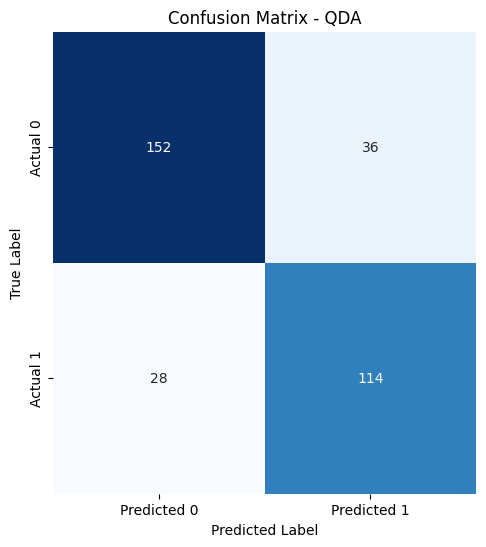

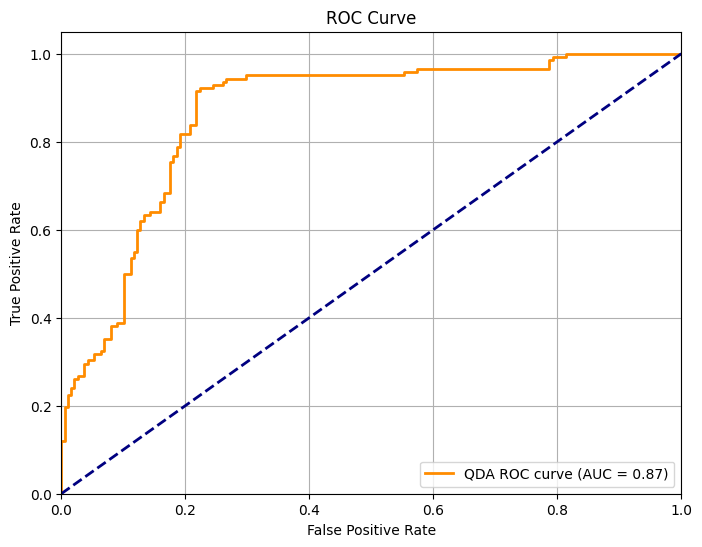

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

X = data[['a1', 'a2', 'a3']]
y = data['counterfeit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)

y_pred_proba_qda = qda.predict_proba(X_test)[:, 1]

# Calculate confusion matrix
y_pred_qda = qda.predict(X_test)
conf_matrix_qda = confusion_matrix(y_test, y_pred_qda)
print("Quadratic Discriminant Analysis Confusion Matrix:")
print(conf_matrix_qda)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.heatmap(conf_matrix_qda, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - QDA')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Calculate AUC score
fpr_qda, tpr_qda, _ = roc_curve(y_test, y_pred_proba_qda)
auc_qda = auc(fpr_qda, tpr_qda)
print(f"Quadratic Discriminant Analysis AUC Score: {auc_qda:.4f}")

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_qda, tpr_qda, color='darkorange', lw=2, label=f'QDA ROC curve (AUC = {auc_qda:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### B.


Perform Gaussian Mixture Discriminant Analysis on this set as described in the `gaussian_mixture_model_EM_algorithm` notebook. Use two components for positives and two components for negatives. Calculate the confusion matrix, AUC score and plot the ROC curve.

In [28]:
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.metrics import confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
from scipy.special import logsumexp

def make_predict_proba(gm0_model, gm1_model, pi1):
    """
    Returns a callable function that predicts the posterior probability of being in class 1
    given data X_data, using trained Gaussian Mixture Models and a prior probability
    """
    log_prior_0 = np.log(1 - pi1)
    log_prior_1 = np.log(pi1)

    def predict_proba_func(X_data):
        log_likelihood_0 = gm0_model.score_samples(X_data)
        log_likelihood_1 = gm1_model.score_samples(X_data)

        log_numerator = log_likelihood_1 + log_prior_1
        log_denominator_term0 = log_likelihood_0 + log_prior_0
        log_denominator_term1 = log_likelihood_1 + log_prior_1

        log_denominator = logsumexp(np.vstack([log_denominator_term0, log_denominator_term1]), axis=0)

        prob_class1 = np.exp(log_numerator - log_denominator)
        return prob_class1

    return predict_proba_func

Estimated prior probability of class 1: 0.4511

Gaussian Mixture Discriminant Analysis Confusion Matrix:
[[180   8]
 [ 24 118]]


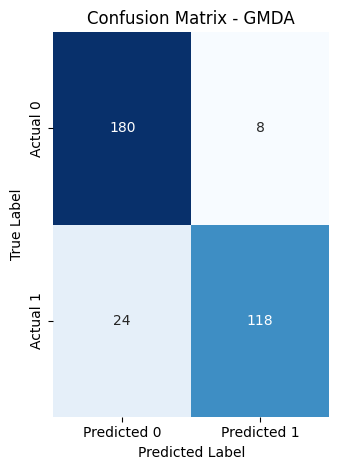

Gaussian Mixture Discriminant Analysis AUC Score: 0.9598


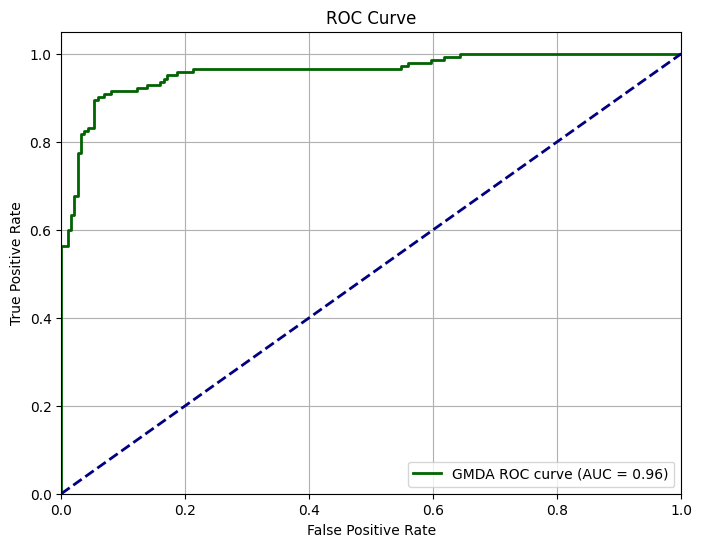

In [31]:
# Separate training by class
X_train_0 = X_train[y_train == 0]
X_train_1 = X_train[y_train == 1]

gm0 = GaussianMixture(n_components=2, random_state=42, covariance_type='full')
gm0.fit(X_train_0)

gm1 = GaussianMixture(n_components=2, random_state=42, covariance_type='full')
gm1.fit(X_train_1)

# Estimate prior probability of class 1 from training data
pi1_estimate_problem_b = y_train.mean()
print(f"Estimated prior probability of class 1: {pi1_estimate_problem_b:.4f}")
gmda_predictor = make_predict_proba(gm0, gm1, pi1=pi1_estimate_problem_b)
y_pred_proba_gmda = gmda_predictor(X_test)

# Calculate confusion matrix
y_pred_gmda = (y_pred_proba_gmda > 0.5).astype(int)
conf_matrix_gmda = confusion_matrix(y_test, y_pred_gmda)
print("\nGaussian Mixture Discriminant Analysis Confusion Matrix:")
print(conf_matrix_gmda)
plt.subplot(1, 2, 2)
sns.heatmap(conf_matrix_gmda, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - GMDA')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.tight_layout()
plt.show()

# Calculate AUC score
fpr_gmda, tpr_gmda, _ = roc_curve(y_test, y_pred_proba_gmda)
auc_gmda = auc(fpr_gmda, tpr_gmda)
print(f"Gaussian Mixture Discriminant Analysis AUC Score: {auc_gmda:.4f}")

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_gmda, tpr_gmda, color='darkgreen', lw=2, label=f'GMDA ROC curve (AUC = {auc_gmda:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

fprs_gmda = fpr_gmda
tprs_gmda = tpr_gmda
aucs_gmda = auc_gmda

In [32]:
mgda = make_predict_proba(gm0, gm1,pi1=0.445)
mgda_test_proba[:10]


array([8.66075361e-07, 1.44300583e-03, 3.53829331e-04, 3.36570959e-02,
       9.74673344e-06, 7.54017864e-06, 9.10003256e-01, 3.52506378e-01,
       9.99918429e-01, 1.00167854e-04])

### C.


Use k-fold cross validation to find the optimal number of gaussian components for each class. As before calculate the confusion matrix, AUC score and plot the ROC curve for the best classifier. Assume that maximal number of components in each class is 12.  


__Hint__ use the `StratifiedKFold` function from scikit-learn library to generate folds.


## D.  


Assume that 1% of all the customers in your store try to pay with a counterfeit 100PLN bill. If you accept the counterfeit bill you loose 100PLN. If you reject a valid bill,  you may loose the purchase, you estimate this loss as 15PLN on average. For each of the three classifiers find the threshold that minimises your losses and calculates the minimum loss for each classifier. Show the optimal classifiers points on the ROC curves.

In [ ]:
fprs, tprs, thds = roc_curve(data_test['counterfeit'],test_proba)

In [ ]:
fprs

In [ ]:
tprs